In [ ]:
# ============================================================
# NOTEBOOK 4 — DOMAIN GENERALIZATION & UNCERTAINTY CALIBRATION
# Paste Universal Cell 0 first, then each CELL block below
# into a separate Colab cell, in order.
# ============================================================

### Universal Cell (Paths + Mount Drive)

In [ ]:
# ── UNIVERSAL CELL 0 ──────────────────────────────────────────────
# It mounts Drive, loads all splits, and builds CONFIG.

from google.colab import drive
import os, json, sys
import pandas as pd

drive.mount('/content/drive', force_remount=False)

BASE = '/content/drive/MyDrive/MedSSL_Research'
assert os.path.exists(BASE), f'Drive folder not found: {BASE}'

# Load master dataframe (created by Notebook 1)
df = pd.read_csv(f'{BASE}/splits/master_dataframe.csv')

# Load official splits — NEVER regenerate these
train_idx = json.load(open(f'{BASE}/splits/train_indices.json'))
val_idx   = json.load(open(f'{BASE}/splits/val_indices.json'))
test_idx  = json.load(open(f'{BASE}/splits/test_indices.json'))
sub10_idx = json.load(open(f'{BASE}/splits/subset_10pct_seed42.json'))
sub20_idx = json.load(open(f'{BASE}/splits/subset_20pct_seed42.json'))

CLASS_NAMES = sorted(df['label_name'].unique().tolist())
NUM_CLASSES = len(CLASS_NAMES)  # should be 6

# Load helper files from Drive
sys.path.insert(0, BASE)
import importlib.util
def load_from_drive(filename, module_name):
    spec = importlib.util.spec_from_file_location(
        module_name, f'{BASE}/{filename}')
    mod = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(mod)
    return mod

aug = load_from_drive('augmentations.py', 'augmentations')
dc  = load_from_drive('dataset_class.py', 'dataset_class')
MedicalImageDataset         = dc.MedicalImageDataset
SUPERVISED_TRAIN_TRANSFORMS = aug.SUPERVISED_TRAIN_TRANSFORMS
SUPERVISED_VAL_TRANSFORMS   = aug.SUPERVISED_VAL_TRANSFORMS
SSL_PRETRAIN_TRANSFORMS     = aug.SSL_PRETRAIN_TRANSFORMS

CONFIG = {
    'base':          BASE,
    'data_dir':      f'{BASE}/dataset/processed',
    'splits_dir':    f'{BASE}/splits',
    'ckpt_dir':      f'{BASE}/checkpoints',
    'results_dir':   f'{BASE}/results',
    'figures_dir':   f'{BASE}/figures',
    'num_classes':   NUM_CLASSES,
    'class_names':   CLASS_NAMES,
    'seed':          42,
    'seeds':         [42, 123, 456],
    'batch_size':    32,
    'epochs':        100,
    'early_stop':    10,
    'lr_backbone':   1e-4,
    'lr_head':       1e-3,
    'weight_decay':  1e-4,
    'use_amp':       True,
    'image_size':    224,
    'subsets': {'10pct': sub10_idx, '20pct': sub20_idx, '100pct': train_idx},
}

os.makedirs(CONFIG['results_dir'], exist_ok=True)
os.makedirs(CONFIG['figures_dir'], exist_ok=True)

print(f'Drive: OK | Classes: {NUM_CLASSES} | ',
      f'Train: {len(train_idx)} | Val: {len(val_idx)} | Test: {len(test_idx)}')

Mounted at /content/drive
Drive: OK | Classes: 6 |  Train: 12591 | Val: 1799 | Test: 3598


### Import All Libraries

In [ ]:

import subprocess, sys

def pip_silent(pkgs):
    subprocess.run([sys.executable, '-m', 'pip', 'install', '--quiet'] + pkgs,
                   capture_output=True)

pip_silent(['torch', 'torchvision', 'timm', 'kornia',
            'numpy', 'pandas', 'scikit-learn',
            'matplotlib', 'seaborn', 'tqdm'])

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as tvm
import timm
import kornia.augmentation as K
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os, json, random, time
from torch.utils.data import DataLoader
from sklearn.metrics import f1_score, accuracy_score
from tqdm.notebook import tqdm

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
    print(f'VRAM   : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')

FIG_DPI  = 300
FIGS_DIR = CONFIG['figures_dir']
RES_DIR  = CONFIG['results_dir']
os.makedirs(FIGS_DIR, exist_ok=True)
os.makedirs(RES_DIR,  exist_ok=True)

MODEL_LABELS = {
    'resnet50_pretrained' : 'ResNet50 (ImageNet)',
    'resnet50_scratch'    : 'ResNet50 (Scratch)',
    'efficientnet_b0'     : 'EfficientNet-B0',
    'mobilevit_xs'        : 'MobileViT-XS',
    'simclr_resnet50'     : 'SimCLR + ResNet50',
    'mae_vits16'          : 'MAE + ViT-S/16',
}
MODEL_COLORS = {
    'resnet50_pretrained' : '#2196F3',
    'resnet50_scratch'    : '#F44336',
    'efficientnet_b0'     : '#4CAF50',
    'mobilevit_xs'        : '#FF9800',
    'simclr_resnet50'     : '#9C27B0',
    'mae_vits16'          : '#00BCD4',
}

print()
print('=' * 55)
print('  CELL 1 COMPLETE')
print('=' * 55)

Device : cuda
GPU    : Tesla T4
VRAM   : 15.6 GB

  CELL 1 COMPLETE


### Load All 6 Trained Models   

In [ ]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 2 — Load All 6 Trained Models                     ║
# ╚══════════════════════════════════════════════════════════╝

def build_model_for_eval(model_name, num_classes):
    """
    Rebuild model architecture matching NB2/NB3 build logic.

    Parameters
    ----------
    model_name  : str
    num_classes : int

    Returns
    -------
    nn.Module  uninitialised model with correct architecture
    """
    if model_name in ('resnet50_pretrained', 'resnet50_scratch'):
        model = tvm.resnet50(weights=None)
        model.fc = nn.Linear(2048, num_classes)

    elif model_name == 'efficientnet_b0':
        model = timm.create_model('efficientnet_b0',
                                  pretrained=False, num_classes=num_classes)

    elif model_name == 'mobilevit_xs':
        model = timm.create_model('mobilevit_xs',
                                  pretrained=False, num_classes=num_classes)

    elif model_name == 'simclr_resnet50':
        backbone = tvm.resnet50(weights=None)
        backbone.fc = nn.Identity()
        model = nn.Sequential(backbone, nn.Linear(2048, num_classes))

    elif model_name == 'mae_vits16':
        encoder = timm.create_model('vit_small_patch16_224',
                                    pretrained=False, num_classes=0)
        model = nn.Sequential(encoder, nn.Linear(384, num_classes))

    else:
        raise ValueError(f'Unknown model: {model_name}')

    return model


def load_best_checkpoint(model_name, subset, seed, num_classes):
    """
    Load best checkpoint for (model, subset, seed).

    Parameters
    ----------
    model_name  : str
    subset      : str   e.g. '100pct'
    seed        : int
    num_classes : int

    Returns
    -------
    nn.Module in eval() on DEVICE, or None if checkpoint missing
    """
    supervised = ['resnet50_pretrained', 'resnet50_scratch',
                  'efficientnet_b0', 'mobilevit_xs']
    if model_name in supervised:
        ckpt_path = (f'{CONFIG["ckpt_dir"]}/supervised/'
                     f'{model_name}_{subset}_seed{seed}_best.pt')
    else:
        ckpt_path = (f'{CONFIG["ckpt_dir"]}/finetuned/'
                     f'{model_name}_{subset}_seed{seed}_best.pt')

    if not os.path.exists(ckpt_path):
        print(f'  [WARN] Not found: {ckpt_path}')
        return None

    model = build_model_for_eval(model_name, num_classes)
    ckpt  = torch.load(ckpt_path, map_location=DEVICE)
    model.load_state_dict(ckpt['model_state'])
    model = model.to(DEVICE).eval()
    print(f'  Loaded : {model_name}')
    return model


MODEL_NAMES = list(MODEL_LABELS.keys())
print('Loading 6 models (seed=42, 100% labels) ...')
models = {}
for mn in MODEL_NAMES:
    m = load_best_checkpoint(mn, '100pct', 42, CONFIG['num_classes'])
    if m is not None:
        models[mn] = m

missing = [mn for mn in MODEL_NAMES if mn not in models]
print(f'\nLoaded: {len(models)}/{len(MODEL_NAMES)}')
if missing:
    print(f'Missing: {missing}')
    print('Ensure NB2 and NB3 completed before running NB4.')

print()
print('=' * 55)
print('  CELL 2 COMPLETE')
print('=' * 55)

Loading 6 models (seed=42, 100% labels) ...
  Loaded : resnet50_pretrained
  Loaded : resnet50_scratch
  Loaded : efficientnet_b0
  Loaded : mobilevit_xs
  Loaded : simclr_resnet50
  Loaded : mae_vits16

Loaded: 6/6

  CELL 2 COMPLETE


### Corruption Pipeline

In [ ]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 3 — Corruption Pipeline                           ║
# ╚══════════════════════════════════════════════════════════╝

CORRUPTIONS = [
    'clean',
    'gaussian_noise_low',
    'gaussian_noise_medium',
    'brightness_up',
    'brightness_down',
    'gaussian_blur_mild',
    'gaussian_blur_strong',
    'contrast_reduction',
    'jpeg_artifacts',
]

CORRUPTION_LABELS = {
    'clean'                 : 'Clean',
    'gaussian_noise_low'    : 'Noise (low)',
    'gaussian_noise_medium' : 'Noise (med)',
    'brightness_up'         : 'Bright +',
    'brightness_down'       : 'Bright -',
    'gaussian_blur_mild'    : 'Blur (mild)',
    'gaussian_blur_strong'  : 'Blur (strong)',
    'contrast_reduction'    : 'Low contrast',
    'jpeg_artifacts'        : 'JPEG Q50',
}


def apply_corruption(imgs, corruption_name):
    """
    Apply a single corruption to a GPU batch of normalised images.

    Parameters
    ----------
    imgs            : Tensor (B, 3, 224, 224) normalised
    corruption_name : str

    Returns
    -------
    Tensor (B, 3, 224, 224) corrupted + still normalised
    """
    x = imgs.float()

    if corruption_name == 'clean':
        return x

    elif corruption_name == 'gaussian_noise_low':
        return x + torch.randn_like(x) * 0.05

    elif corruption_name == 'gaussian_noise_medium':
        return x + torch.randn_like(x) * 0.10

    elif corruption_name == 'brightness_up':
        return x * 1.3

    elif corruption_name == 'brightness_down':
        return x * 0.7

    elif corruption_name == 'gaussian_blur_mild':
        blur = K.RandomGaussianBlur((5, 5), (1.0, 1.0), p=1.0)
        return blur(x)

    elif corruption_name == 'gaussian_blur_strong':
        blur = K.RandomGaussianBlur((9, 9), (2.0, 2.0), p=1.0)
        return blur(x)

    elif corruption_name == 'contrast_reduction':
        mean = x.mean(dim=[2, 3], keepdim=True)
        return mean + (x - mean) * 0.7

    elif corruption_name == 'jpeg_artifacts':
        # Simulate JPEG Q50 via quantisation approximation on GPU
        x_uint = ((x * 0.229 + 0.485).clamp(0, 1) * 255)
        x_q    = (x_uint / 16).floor() * 16
        return (x_q / 255 - 0.485) / 0.229

    else:
        raise ValueError(f'Unknown corruption: {corruption_name}')


# Base test loader — clean images, corruption applied at eval time
base_test_loader = DataLoader(
    MedicalImageDataset(df, test_idx, transform=SUPERVISED_VAL_TRANSFORMS),
    batch_size=32, shuffle=False, num_workers=0, pin_memory=True
)

print(f'Test set         : {len(test_idx):,} images')
print(f'Corruptions      : {len(CORRUPTIONS)-1} + clean')
print(f'Total evals      : {len(models)} × {len(CORRUPTIONS)} = '
      f'{len(models)*len(CORRUPTIONS)}')
print()
print('=' * 55)
print('  CELL 3 COMPLETE — corruption pipeline ready')
print('=' * 55)

Test set         : 3,598 images
Corruptions      : 8 + clean
Total evals      : 6 × 9 = 54

  CELL 3 COMPLETE — corruption pipeline ready


### Robustness Evaluation

Robustness results already exist. Loading from Drive.
                        clean  gaussian_noise_low  gaussian_noise_medium  \
Model                                                                      
resnet50_pretrained  0.933410            0.907099               0.771942   
resnet50_scratch     0.896053            0.895346               0.890722   
efficientnet_b0      0.952897            0.643189               0.073317   
mobilevit_xs         0.938586            0.849003               0.642836   
simclr_resnet50      0.950651            0.949217               0.919346   
mae_vits16           0.812858            0.809897               0.810324   

                     brightness_up  brightness_down  gaussian_blur_mild  \
Model                                                                     
resnet50_pretrained       0.911311         0.890077            0.523530   
resnet50_scratch          0.894692         0.882216            0.875919   
efficientnet_b0           0.898098   

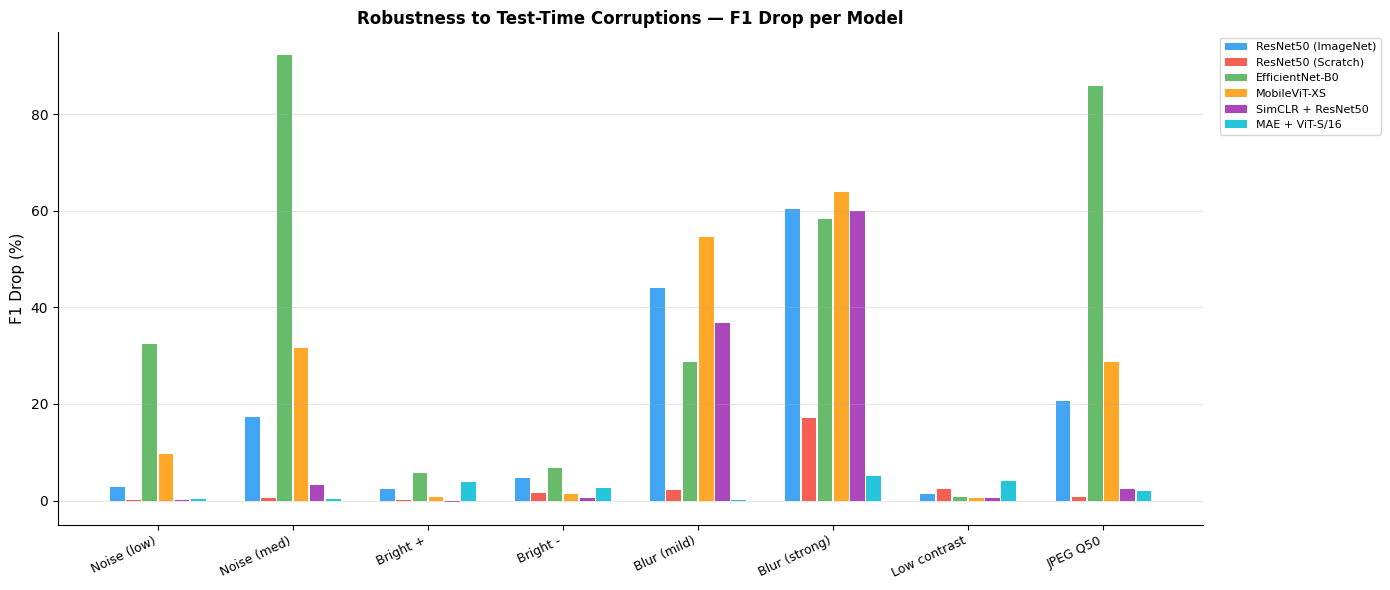

  Saved: /content/drive/MyDrive/MedSSL_Research/figures/robustness_barchart.png

Figure B: Robustness heatmap ...


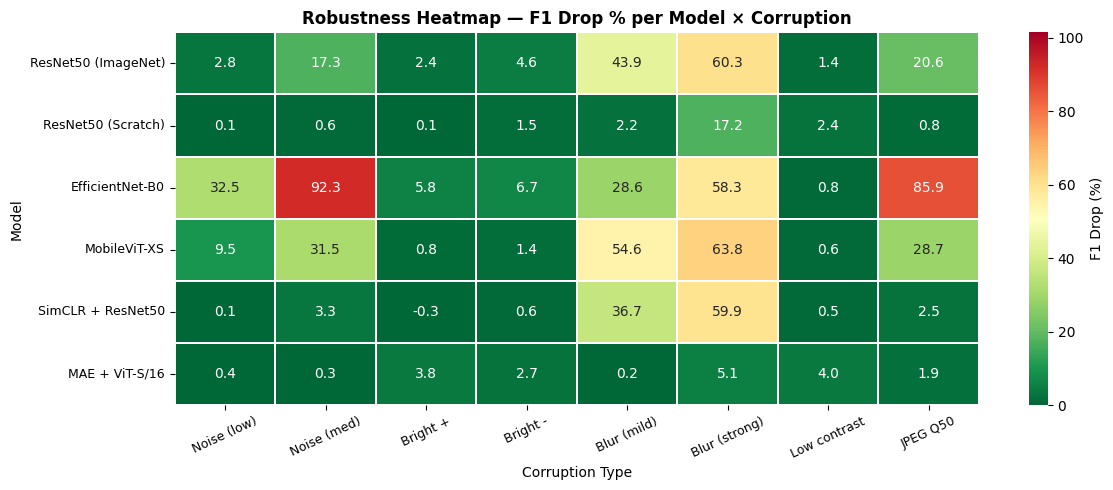

  Saved: /content/drive/MyDrive/MedSSL_Research/figures/robustness_heatmap.png

  CELL 4 COMPLETE — robustness evaluation done


In [ ]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 4 — Robustness Evaluation                         ║
# ╚══════════════════════════════════════════════════════════╝

ROBUSTNESS_CSV = f'{RES_DIR}/robustness_results.csv'


def evaluate_corrupted(model, loader, corruption_name, device):
    """
    Evaluate model on test set with a specific corruption applied per batch.

    Parameters
    ----------
    model           : nn.Module in eval() mode
    loader          : DataLoader yielding clean images
    corruption_name : str
    device          : torch.device

    Returns
    -------
    float  macro F1 score
    """
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for imgs, labels in loader:
            imgs   = imgs.to(device)
            labels = labels.to(device)

            # Apply corruption on GPU
            imgs_c = apply_corruption(imgs, corruption_name)

            with torch.amp.autocast(device_type=device.type,
                                    enabled=(device.type == 'cuda')):
                logits = model(imgs_c)

            preds = logits.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return float(f1_score(all_labels, all_preds,
                           average='macro', zero_division=0))


# Check if already done
if os.path.exists(ROBUSTNESS_CSV):
    print('Robustness results already exist. Loading from Drive.')
    robustness_df = pd.read_csv(ROBUSTNESS_CSV, index_col=0)
    print(robustness_df)
else:
    print('Running robustness evaluation ...')
    print(f'{len(models)} models × {len(CORRUPTIONS)} corruptions\n')

    results = {}
    for mn, model in models.items():
        results[mn] = {}
        for corruption in CORRUPTIONS:
            f1 = evaluate_corrupted(model, base_test_loader,
                                    corruption, DEVICE)
            results[mn][corruption] = f1
            label = CORRUPTION_LABELS[corruption]
            print(f'  {MODEL_LABELS[mn]:<28} {label:<18} F1={f1:.4f}')
        print()

    # Build DataFrame
    robustness_df = pd.DataFrame(results).T
    robustness_df.index.name = 'Model'

    # Add drop% columns
    for corr in CORRUPTIONS[1:]:   # skip clean
        col_drop = f'{corr}_drop_pct'
        robustness_df[col_drop] = (
            (robustness_df['clean'] - robustness_df[corr])
            / robustness_df['clean'] * 100
        ).round(2)

    # Average drop across all corruptions
    drop_cols = [f'{c}_drop_pct' for c in CORRUPTIONS[1:]]
    robustness_df['avg_drop_pct'] = robustness_df[drop_cols].mean(axis=1).round(2)

    robustness_df.to_csv(ROBUSTNESS_CSV)
    print(f'Saved: {ROBUSTNESS_CSV}')

# Print summary
print('\nRobustness Summary (avg F1 drop % across 8 corruptions):')
summary = robustness_df[['clean', 'avg_drop_pct']].copy()
summary.index = [MODEL_LABELS.get(i, i) for i in summary.index]
summary.columns = ['Clean F1', 'Avg Drop %']
print(summary.to_string())

# ── Figure A: Grouped bar chart ───────────────────────────────
print('\nFigure A: Robustness bar chart ...')
drop_cols_clean = [f'{c}_drop_pct' for c in CORRUPTIONS[1:]]
plot_data = robustness_df[drop_cols_clean].copy()
plot_data.index = [MODEL_LABELS.get(i, i) for i in plot_data.index]
plot_data.columns = [CORRUPTION_LABELS[c] for c in CORRUPTIONS[1:]]

fig, ax = plt.subplots(figsize=(14, 6))
x      = np.arange(len(CORRUPTIONS) - 1)
n_models = len(plot_data)
width  = 0.12
offsets = np.linspace(-(n_models-1)/2, (n_models-1)/2, n_models) * width

for i, (mn_label, row) in enumerate(plot_data.iterrows()):
    orig_key = [k for k, v in MODEL_LABELS.items() if v == mn_label]
    color    = MODEL_COLORS.get(orig_key[0] if orig_key else '', '#888888')
    ax.bar(x + offsets[i], row.values, width=width*0.9,
           label=mn_label, color=color, alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(plot_data.columns, rotation=25, ha='right', fontsize=9)
ax.set_ylabel('F1 Drop (%)', fontsize=11)
ax.set_title('Robustness to Test-Time Corruptions — F1 Drop per Model',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=8, bbox_to_anchor=(1.01, 1), loc='upper left')
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
path_a = f'{FIGS_DIR}/robustness_barchart.png'
plt.savefig(path_a, dpi=FIG_DPI, bbox_inches='tight')
plt.show()
print(f'  Saved: {path_a}')

# ── Figure B: Heatmap ─────────────────────────────────────────
print('\nFigure B: Robustness heatmap ...')
heat_data = plot_data.copy()
fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(heat_data, annot=True, fmt='.1f', cmap='RdYlGn_r',
            ax=ax, linewidths=0.3, cbar_kws={'label': 'F1 Drop (%)'},
            vmin=0, vmax=heat_data.values.max() * 1.1)
ax.set_title('Robustness Heatmap — F1 Drop % per Model × Corruption',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Corruption Type', fontsize=10)
ax.set_ylabel('Model', fontsize=10)
ax.tick_params(axis='x', rotation=25, labelsize=9)
ax.tick_params(axis='y', rotation=0,  labelsize=9)
plt.tight_layout()
path_b = f'{FIGS_DIR}/robustness_heatmap.png'
plt.savefig(path_b, dpi=FIG_DPI, bbox_inches='tight')
plt.show()
print(f'  Saved: {path_b}')

print()
print('=' * 55)
print('  CELL 4 COMPLETE — robustness evaluation done')
print('=' * 55)

### MC Dropout Setup   

In [ ]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 5 — MC Dropout Setup                              ║
# ╚══════════════════════════════════════════════════════════╝

import copy


def enable_mc_dropout(model):
    """
    Activate dropout layers for MC Dropout uncertainty estimation.
    Sets model to eval() then re-enables all Dropout layers.
    Handles standard Dropout, Dropout2d, and ViT attention dropout.

    Parameters
    ----------
    model : nn.Module

    Returns
    -------
    nn.Module with dropout layers in training mode
    """
    model.eval()
    for m in model.modules():
        if isinstance(m, (nn.Dropout, nn.Dropout2d)):
            m.train()
    return model


def prepare_mc_model(model, model_name, dropout_p=0.1):
    """
    Return an MC Dropout-ready copy of model.

    For models that already contain nn.Dropout layers (e.g. ResNet50),
    enable_mc_dropout() is sufficient.  For models with NO dropout layers
    (EfficientNet-B0, MobileViT-XS, SimCLR, MAE), a fresh Dropout layer is
    injected immediately before the classification head so that each of the
    T forward passes differs stochastically.

    Parameters
    ----------
    model      : nn.Module   original trained model (not modified in-place)
    model_name : str
    dropout_p  : float       dropout probability for injection (default 0.1)

    Returns
    -------
    nn.Module  MC-ready copy, placed on the same device as the original
    """
    mc = copy.deepcopy(model)

    # Check whether the model already has any Dropout modules
    has_dropout = any(
        isinstance(m, (nn.Dropout, nn.Dropout2d))
        for m in mc.modules()
    )

    if has_dropout:
        # Just re-enable existing dropout layers at inference time
        enable_mc_dropout(mc)
        return mc

    # No dropout found — inject before the classification head
    dp = nn.Dropout(p=dropout_p)

    if model_name in ('resnet50_pretrained', 'resnet50_scratch'):
        # mc.fc is nn.Linear(2048, num_classes)
        mc.fc = nn.Sequential(dp, mc.fc)

    elif model_name == 'efficientnet_b0':
        # timm EfficientNet: classification head is mc.classifier
        mc.classifier = nn.Sequential(dp, mc.classifier)

    elif model_name == 'mobilevit_xs':
        # timm MobileViT: classification head is mc.head
        mc.head = nn.Sequential(dp, mc.head)

    elif model_name == 'simclr_resnet50':
        # nn.Sequential(backbone, nn.Linear(2048, C))
        mc = nn.Sequential(mc[0], dp, mc[1])

    elif model_name == 'mae_vits16':
        # nn.Sequential(vit_encoder, nn.Linear(384, C))
        mc = nn.Sequential(mc[0], dp, mc[1])

    # Move to same device as original, then enable the injected dropout
    mc = mc.to(next(model.parameters()).device)
    enable_mc_dropout(mc)
    return mc


def mc_dropout_predict(model, loader, T=20, device=DEVICE):
    """
    Run T stochastic forward passes for MC Dropout uncertainty estimation.

    Parameters
    ----------
    model  : nn.Module   already prepared by prepare_mc_model()
    loader : DataLoader
    T      : int   number of stochastic passes (20 is standard)
    device : torch.device

    Returns
    -------
    mean_probs  : np.ndarray (N, C)  mean softmax probabilities
    variances   : np.ndarray (N, C)  variance across T passes
    true_labels : np.ndarray (N,)    ground truth labels
    """
    # Keep BatchNorm in eval() but Dropout in train() — enable_mc_dropout
    # already set this; call again to be safe after any device moves.
    enable_mc_dropout(model)
    all_pass_probs = []
    all_labels     = []

    with torch.no_grad():
        for imgs, labels in tqdm(loader, desc=f'  MC Dropout T={T}',
                                 leave=False, mininterval=5.0):
            imgs = imgs.to(device)
            pass_probs = []
            for _ in range(T):
                with torch.amp.autocast(device_type=device.type,
                                        enabled=(device.type == 'cuda')):
                    logits = model(imgs)
                probs = F.softmax(logits, dim=1).cpu().numpy()
                pass_probs.append(probs)
            # Stack: (T, B, C)
            all_pass_probs.append(np.stack(pass_probs, axis=0))
            all_labels.append(labels.numpy())

    # Concatenate along sample dimension
    all_pass_probs = np.concatenate(all_pass_probs, axis=1)  # (T, N, C)
    mean_probs     = all_pass_probs.mean(axis=0)              # (N, C)
    variances      = all_pass_probs.var(axis=0)               # (N, C)
    true_labels    = np.concatenate(all_labels)               # (N,)

    return mean_probs, variances, true_labels


print('MC Dropout functions defined:')
print('  prepare_mc_model(model, model_name)  — NEW: injects dropout if needed')
print('  enable_mc_dropout(model)')
print('  mc_dropout_predict(model, loader, T=20)')
print()
print('=' * 55)
print('  CELL 5 COMPLETE')
print('=' * 55)


MC Dropout functions defined:
  prepare_mc_model(model, model_name)  — NEW: injects dropout if needed
  enable_mc_dropout(model)
  mc_dropout_predict(model, loader, T=20)

  CELL 5 COMPLETE


### Calibration Metrics   

In [ ]:
# Run this ONCE to create a zip on Drive
# After this, Cell 2b unzips in ~2 min instead of copying in 2 hours

import os, time, subprocess

DRIVE_DATA = '/content/drive/MyDrive/MedSSL_Research/dataset/processed'
LOCAL_DATA = '/content/chest_data'
ZIP_DIR    = '/content/drive/MyDrive/MedSSL_Research/dataset/class_zips'

os.makedirs(LOCAL_DATA, exist_ok=True)
os.makedirs(ZIP_DIR,    exist_ok=True)

# ── Check if already done this session ───────────────────────
total_local = sum(len(f) for _, _, f in os.walk(LOCAL_DATA))
print(f'Files already on local SSD: {total_local:,}')

if total_local >= len(df) * 0.95:
    print('Already copied this session. Skipping copy.')

else:
    # ── Step 1: Create per-class zips on Drive (ONE TIME ONLY) ─
    # Each class zip is ~400-500MB — unzipping in parallel is fast
    classes_on_drive = [
        c for c in sorted(os.listdir(DRIVE_DATA))
        if os.path.isdir(os.path.join(DRIVE_DATA, c))
    ]
    zips_exist = all(
        os.path.exists(f'{ZIP_DIR}/{c}.zip') for c in classes_on_drive
    )

    if not zips_exist:
        print('Creating per-class zip files on Drive (one-time, ~5-10 min) ...')
        for cls in classes_on_drive:
            zip_path = f'{ZIP_DIR}/{cls}.zip'
            if os.path.exists(zip_path):
                print(f'  Already exists: {cls}.zip')
                continue
            print(f'  Zipping {cls} ...', end=' ', flush=True)
            t0 = time.time()
            os.system(f'cd "{DRIVE_DATA}" && zip -r -q "{zip_path}" "{cls}/"')
            size = os.path.getsize(zip_path) / 1e6
            print(f'{size:.0f} MB  ({time.time()-t0:.0f}s)')
        print('All class zips created. Future sessions will be fast.')
    else:
        print('Class zips already exist on Drive.')

Files already on local SSD: 0
Class zips already exist on Drive.


In [ ]:
 # ── Step 2: Unzip all classes in parallel ─────────────────

print(f'\nUnzipping all classes to local SSD in parallel ...')
t0 = time.time()

procs = []
for cls_zip in sorted(os.listdir(ZIP_DIR)):
    if not cls_zip.endswith('.zip'):
        continue
    zip_path = os.path.join(ZIP_DIR, cls_zip)
    proc = subprocess.Popen(
        ['unzip', '-q', '-o', zip_path, '-d', LOCAL_DATA],
        stdout=subprocess.DEVNULL,
        stderr=subprocess.DEVNULL
    )
    procs.append((cls_zip, proc))
    print(f'  Started: {cls_zip}')

for cls_zip, proc in procs:
    proc.wait()
    print(f'  Done   : {cls_zip}')

elapsed = (time.time() - t0) / 60
total_local = sum(len(f) for _, _, f in os.walk(LOCAL_DATA))
print(f'\nAll unzipped in {elapsed:.1f} min  —  {total_local:,} files')

# ── Fix df paths to point to local SSD ───────────────────────
print('\nUpdating df image_path to local SSD ...')

def fix_path(p):
    """Rebuild path using just class_folder/filename from any prefix."""
    parts = p.replace('\\', '/').split('/')
    # parts[-1] = filename, parts[-2] = class folder
    return os.path.join(LOCAL_DATA, parts[-2], parts[-1])

df['image_path'] = df['image_path'].apply(fix_path)

# ── Verify ────────────────────────────────────────────────────
missing = df['image_path'].apply(lambda p: not os.path.exists(p)).sum()
print(f'Missing files: {missing} / {len(df)}')

if missing == 0:
    print('All paths verified. Ready to train.')
    print(f'Sample: {df["image_path"].iloc[0]}')
else:
    print(f'[WARN] {missing} files missing.')
    print('Check that class folder names in zip match df label_name column.')
    print('df label_name values:', df['label_name'].unique().tolist())
    print('Local SSD folders   :', os.listdir(LOCAL_DATA))

print()
print('=' * 55)
print('  CELL 2b COMPLETE')
print(f'  Local SSD : {LOCAL_DATA}')
print(f'  Files     : {total_local:,}')
print('  Per-session cost: ~2-3 min unzip')
print('=' * 55)



Unzipping all classes to local SSD in parallel ...
  Started: covid-19.zip
  Started: emphysema.zip
  Started: normal.zip
  Started: pneumonia-bacterial.zip
  Started: pneumonia-viral.zip
  Started: tuberculosis.zip
  Done   : covid-19.zip
  Done   : emphysema.zip
  Done   : normal.zip
  Done   : pneumonia-bacterial.zip
  Done   : pneumonia-viral.zip
  Done   : tuberculosis.zip

All unzipped in 0.2 min  —  17,988 files

Updating df image_path to local SSD ...
Missing files: 0 / 17988
All paths verified. Ready to train.
Sample: /content/chest_data/covid-19/train_COVID-3132.jpg

  CELL 2b COMPLETE
  Local SSD : /content/chest_data
  Files     : 17,988
  Per-session cost: ~2-3 min unzip


In [ ]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 6 — Calibration Metrics                           ║
# ╚══════════════════════════════════════════════════════════╝

CALIBRATION_CSV = f'{RES_DIR}/calibration_results.csv'


def compute_ece(mean_probs, labels, n_bins=15):
    """
    Expected Calibration Error (15-bin).

    Parameters
    ----------
    mean_probs : np.ndarray (N, C)
    labels     : np.ndarray (N,)
    n_bins     : int

    Returns
    -------
    float ECE in [0, 1]
    """
    max_conf    = mean_probs.max(axis=1)
    predictions = mean_probs.argmax(axis=1)
    correct     = (predictions == labels).astype(float)
    bins        = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    for i in range(n_bins):
        mask = (max_conf >= bins[i]) & (max_conf < bins[i + 1])
        if mask.sum() > 0:
            acc  = correct[mask].mean()
            conf = max_conf[mask].mean()
            ece += (mask.sum() / len(labels)) * abs(acc - conf)
    return float(ece)


def compute_mce(mean_probs, labels, n_bins=15):
    """
    Maximum Calibration Error — worst-case bin.

    Parameters
    ----------
    mean_probs : np.ndarray (N, C)
    labels     : np.ndarray (N,)
    n_bins     : int

    Returns
    -------
    float MCE in [0, 1]
    """
    max_conf    = mean_probs.max(axis=1)
    predictions = mean_probs.argmax(axis=1)
    correct     = (predictions == labels).astype(float)
    bins        = np.linspace(0, 1, n_bins + 1)
    mce = 0.0
    for i in range(n_bins):
        mask = (max_conf >= bins[i]) & (max_conf < bins[i + 1])
        if mask.sum() > 0:
            acc  = correct[mask].mean()
            conf = max_conf[mask].mean()
            mce  = max(mce, abs(acc - conf))
    return float(mce)


def overconfidence_score(mean_probs, labels, threshold=0.8):
    """
    Fraction of WRONG predictions where max confidence > threshold.
    High score = dangerous overconfidence for clinical deployment.

    Parameters
    ----------
    mean_probs : np.ndarray (N, C)
    labels     : np.ndarray (N,)
    threshold  : float  confidence threshold (default 0.8)

    Returns
    -------
    float  overconfidence score in [0, 1]
    """
    max_conf    = mean_probs.max(axis=1)
    predictions = mean_probs.argmax(axis=1)
    wrong       = predictions != labels
    overconf    = (max_conf > threshold) & wrong
    return float(overconf.sum() / max(wrong.sum(), 1))


# Run MC Dropout on all models
if os.path.exists(CALIBRATION_CSV):
    print('Calibration results already exist. Loading from Drive.')
    calibration_df = pd.read_csv(CALIBRATION_CSV, index_col=0)
    # Reload MC results for reliability diagrams
    mc_results = {}
    for mn in models:
        mc_json = f'{RES_DIR}/mc_dropout_{mn}.json'
        if os.path.exists(mc_json):
            with open(mc_json) as f:
                d = json.load(f)
            mc_results[mn] = {
                'mean_probs' : np.array(d['mean_probs']),
                'variances'  : np.array(d['variances']),
                'true_labels': np.array(d['true_labels']),
            }
    print(calibration_df)
else:
    print('Running MC Dropout (T=20) on all 6 models ...')
    mc_results = {}
    calib_rows = []

    for mn, model in models.items():
        print(f'\n  {MODEL_LABELS[mn]} ...')
        mc_model = prepare_mc_model(model, mn)
        mean_probs, variances, true_labels = mc_dropout_predict(
            mc_model, base_test_loader, T=20, device=DEVICE)

        mc_results[mn] = {
            'mean_probs' : mean_probs,
            'variances'  : variances,
            'true_labels': true_labels,
        }

        # Save MC results for later use (reliability diagrams)
        mc_json = f'{RES_DIR}/mc_dropout_{mn}.json'
        with open(mc_json, 'w') as f:
            json.dump({
                'mean_probs' : mean_probs.tolist(),
                'variances'  : variances.tolist(),
                'true_labels': true_labels.tolist(),
            }, f)

        ece   = compute_ece(mean_probs, true_labels)
        mce   = compute_mce(mean_probs, true_labels)
        oconf = overconfidence_score(mean_probs, true_labels)
        mv    = float(variances.mean())
        acc   = float(accuracy_score(true_labels, mean_probs.argmax(axis=1)))
        f1    = float(f1_score(true_labels, mean_probs.argmax(axis=1),
                               average='macro', zero_division=0))

        calib_rows.append({
            'Model'            : MODEL_LABELS[mn],
            'Accuracy'         : round(acc, 4),
            'Macro_F1'         : round(f1,  4),
            'ECE'              : round(ece,   4),
            'MCE'              : round(mce,   4),
            'Overconfidence%'  : round(oconf * 100, 2),
            'Mean_Variance'    : round(mv, 6),
        })
        print(f'    ECE={ece:.4f}  MCE={mce:.4f}  '
              f'Overconf={oconf*100:.1f}%  MeanVar={mv:.6f}')

    calibration_df = pd.DataFrame(calib_rows).set_index('Model')
    calibration_df.to_csv(CALIBRATION_CSV)
    print(f'\nSaved: {CALIBRATION_CSV}')

print('\nCalibration Results:')
print(calibration_df.to_string())

# Best and worst calibrated
best_cal  = calibration_df['ECE'].idxmin()
worst_cal = calibration_df['ECE'].idxmax()
most_over = calibration_df['Overconfidence%'].idxmax()
print(f'\nBest calibrated  : {best_cal}  (ECE={calibration_df.loc[best_cal,"ECE"]:.4f})')
print(f'Worst calibrated : {worst_cal} (ECE={calibration_df.loc[worst_cal,"ECE"]:.4f})')
print(f'Most overconfident: {most_over} ({calibration_df.loc[most_over,"Overconfidence%"]:.1f}%)')

print()
print('=' * 55)
print('  CELL 6 COMPLETE — calibration metrics done')
print('=' * 55)

Calibration results already exist. Loading from Drive.
                     Accuracy  Macro_F1     ECE     MCE  Overconfidence%  \
Model                                                                      
ResNet50 (ImageNet)    0.9339    0.9334  0.0270  0.1313            55.88   
ResNet50 (Scratch)     0.8972    0.8961  0.0240  0.6272            38.92   
EfficientNet-B0        0.9533    0.9529  0.0259  0.4629            67.26   
MobileViT-XS           0.9389    0.9386  0.0312  0.4463            55.00   
SimCLR + ResNet50      0.9511    0.9507  0.0280  0.3450            67.05   
MAE + ViT-S/16         0.8177    0.8129  0.0268  0.6855            30.18   

                     Mean_Variance  
Model                               
ResNet50 (ImageNet)            0.0  
ResNet50 (Scratch)             0.0  
EfficientNet-B0                0.0  
MobileViT-XS                   0.0  
SimCLR + ResNet50              0.0  
MAE + ViT-S/16                 0.0  

Calibration Results:
                  

## Brier score + NLL

In [ ]:
import numpy as np, json

def brier_score_multiclass(probs, labels, n_classes):
    onehot = np.eye(n_classes)[labels]
    return float(np.mean(np.sum((probs - onehot) ** 2, axis=1)))

def nll_score(probs, labels, eps=1e-12):
    probs_clipped = np.clip(probs, eps, 1.0)
    true_class_probs = probs_clipped[np.arange(len(labels)), labels]
    return float(-np.mean(np.log(true_class_probs)))

def bootstrap_ci_1d(values, n_boot=1000, seed=42):
    rng = np.random.RandomState(seed)
    n = len(values)
    means = [values[rng.randint(0, n, n)].mean() for _ in range(n_boot)]
    lo, hi = np.percentile(means, [2.5, 97.5])
    return float(lo), float(hi)

print('Computing Brier score and NLL from saved MC Dropout outputs ...')
print(f'{"Model":<28} {"Brier":>10} {"Brier 95% CI":>22} {"NLL":>10} {"NLL 95% CI":>22}')

brier_nll_rows = []
for mn in models:  # reuses the `models` dict already loaded earlier in this notebook
    with open(f'{RES_DIR}/mc_dropout_{mn}.json') as f:
        d = json.load(f)
    probs  = np.array(d['mean_probs'])
    labels = np.array(d['true_labels'])
    n_classes = probs.shape[1]

    brier = brier_score_multiclass(probs, labels, n_classes)
    nll   = nll_score(probs, labels)

    onehot = np.eye(n_classes)[labels]
    per_sample_brier = np.sum((probs - onehot) ** 2, axis=1)
    per_sample_nll   = -np.log(np.clip(probs[np.arange(len(labels)), labels], 1e-12, 1.0))
    brier_lo, brier_hi = bootstrap_ci_1d(per_sample_brier)
    nll_lo, nll_hi     = bootstrap_ci_1d(per_sample_nll)

    print(f'{MODEL_LABELS[mn]:<28} {brier:>10.4f} [{brier_lo:.4f}, {brier_hi:.4f}]   '
          f'{nll:>10.4f} [{nll_lo:.4f}, {nll_hi:.4f}]')

    brier_nll_rows.append({'Model': MODEL_LABELS[mn], 'model_key': mn,
        'Brier': round(brier,4), 'Brier_CI_lo': round(brier_lo,4), 'Brier_CI_hi': round(brier_hi,4),
        'NLL': round(nll,4), 'NLL_CI_lo': round(nll_lo,4), 'NLL_CI_hi': round(nll_hi,4)})

brier_nll_df = pd.DataFrame(brier_nll_rows)
brier_nll_df.to_csv(f'{RES_DIR}/brier_nll_results.csv', index=False)
print(f'\nSaved to {RES_DIR}/brier_nll_results.csv')
brier_nll_df

Computing Brier score and NLL from saved MC Dropout outputs ...
Model                             Brier           Brier 95% CI        NLL             NLL 95% CI
ResNet50 (ImageNet)              0.1082 [0.0965, 0.1203]       0.2212 [0.1951, 0.2511]
ResNet50 (Scratch)               0.1528 [0.1404, 0.1655]       0.2715 [0.2468, 0.2971]
EfficientNet-B0                  0.0766 [0.0655, 0.0872]       0.1988 [0.1605, 0.2393]
MobileViT-XS                     0.0941 [0.0825, 0.1063]       0.1966 [0.1695, 0.2257]
SimCLR + ResNet50                0.0803 [0.0693, 0.0926]       0.2643 [0.2137, 0.3230]
MAE + ViT-S/16                   0.2589 [0.2451, 0.2734]       0.4494 [0.4233, 0.4756]

Saved to /content/drive/MyDrive/MedSSL_Research/results/brier_nll_results.csv


,Model,model_key,Brier,Brier_CI_lo,Brier_CI_hi,NLL,NLL_CI_lo,NLL_CI_hi
0,ResNet50 (ImageNet),resnet50_pretrained,0.1082,0.0965,0.1203,0.2212,0.1951,0.2511
1,ResNet50 (Scratch),resnet50_scratch,0.1528,0.1404,0.1655,0.2715,0.2468,0.2971
2,EfficientNet-B0,efficientnet_b0,0.0766,0.0655,0.0872,0.1988,0.1605,0.2393
3,MobileViT-XS,mobilevit_xs,0.0941,0.0825,0.1063,0.1966,0.1695,0.2257
4,SimCLR + ResNet50,simclr_resnet50,0.0803,0.0693,0.0926,0.2643,0.2137,0.3230
5,MAE + ViT-S/16,mae_vits16,0.2589,0.2451,0.2734,0.4494,0.4233,0.4756


### Reliability Diagrams

Figure: Reliability diagrams (2×3 grid) ...


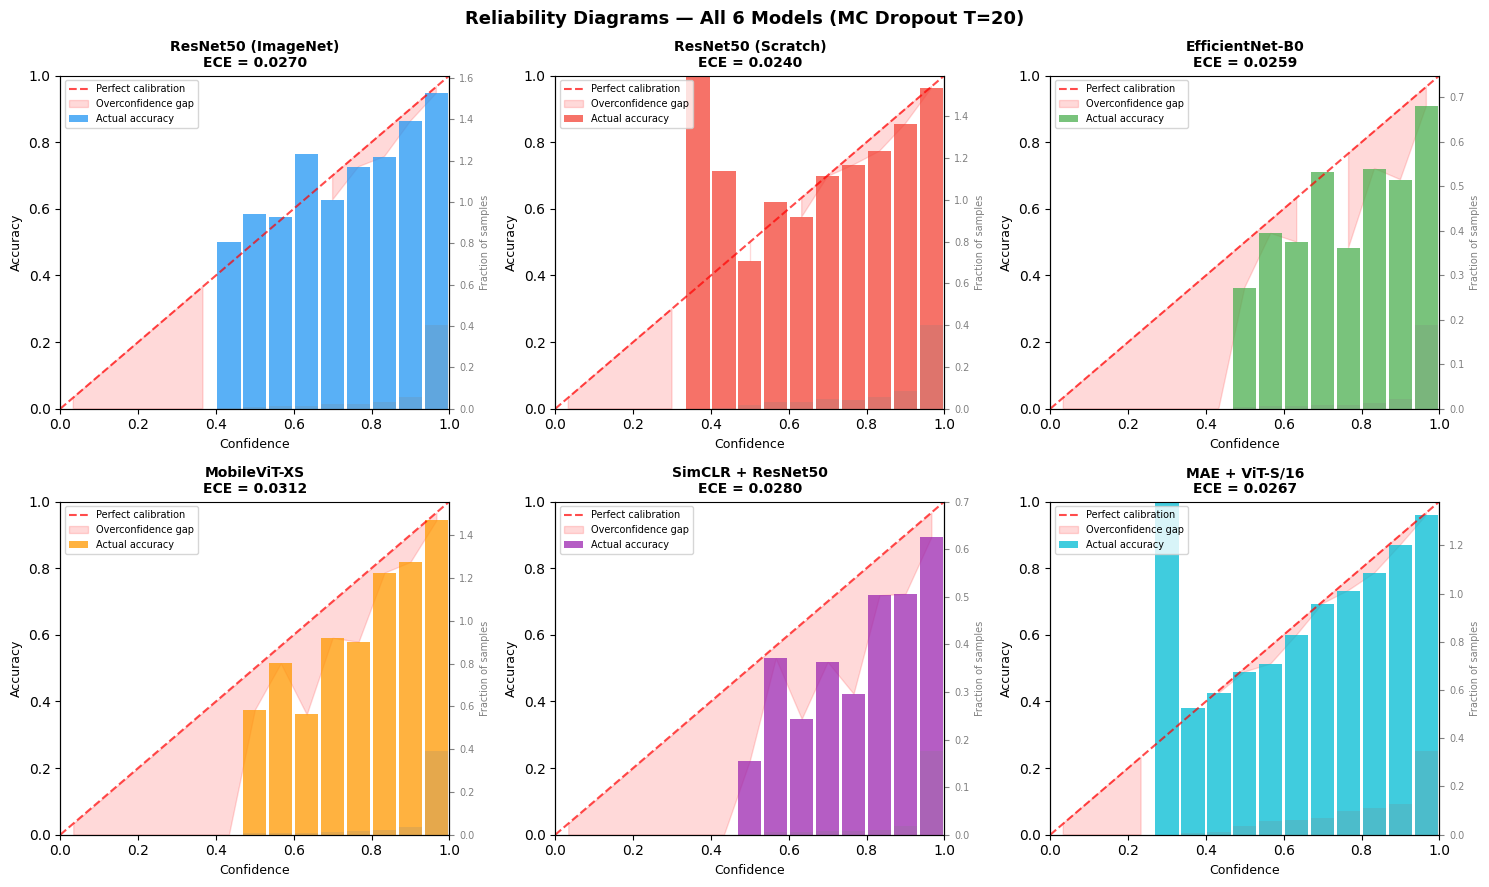

  Saved: /content/drive/MyDrive/MedSSL_Research/figures/reliability_diagrams_6models.png

Figure: Confidence histograms ...


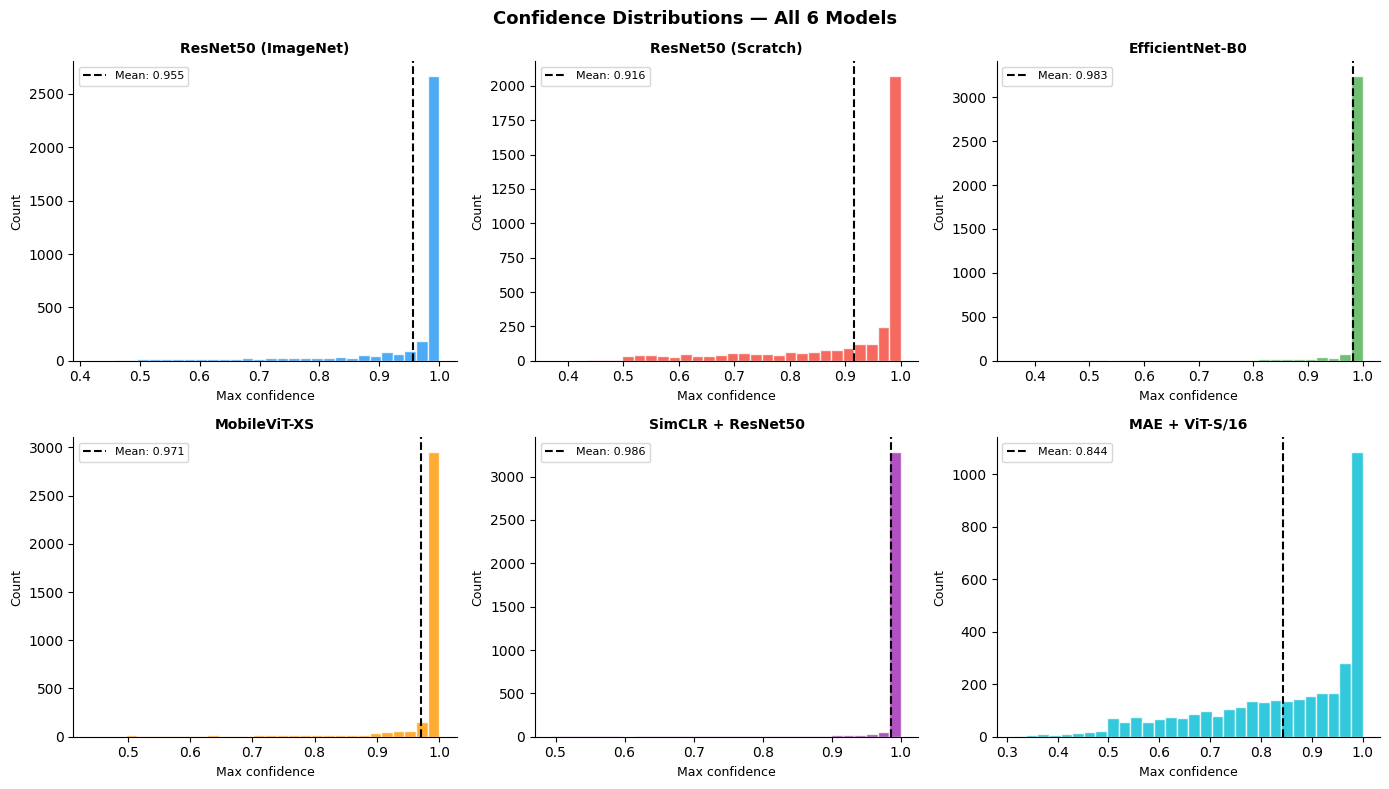

  Saved: /content/drive/MyDrive/MedSSL_Research/figures/confidence_histograms.png

  CELL 7 COMPLETE — reliability diagrams saved


In [ ]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 7 — Reliability Diagrams                           ║
# ╚══════════════════════════════════════════════════════════╝

print('Figure: Reliability diagrams (2×3 grid) ...')

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()
n_bins = 15
bins   = np.linspace(0, 1, n_bins + 1)
bin_centres = (bins[:-1] + bins[1:]) / 2

for ax_idx, mn in enumerate(MODEL_NAMES):
    ax = axes[ax_idx]

    if mn not in mc_results:
        ax.set_title(f'{MODEL_LABELS[mn]}\n(no data)', fontsize=10)
        continue

    mean_probs  = mc_results[mn]['mean_probs']
    true_labels = mc_results[mn]['true_labels']
    max_conf    = mean_probs.max(axis=1)
    predictions = mean_probs.argmax(axis=1)
    correct     = (predictions == true_labels).astype(float)

    bin_accs   = []
    bin_confs  = []
    bin_counts = []

    for i in range(n_bins):
        mask = (max_conf >= bins[i]) & (max_conf < bins[i + 1])
        if mask.sum() > 0:
            bin_accs.append(correct[mask].mean())
            bin_confs.append(max_conf[mask].mean())
            bin_counts.append(mask.sum())
        else:
            bin_accs.append(0.0)
            bin_confs.append(bin_centres[i])
            bin_counts.append(0)

    bin_accs   = np.array(bin_accs)
    bin_confs  = np.array(bin_confs)
    bin_counts = np.array(bin_counts)

    # Perfect calibration diagonal
    ax.plot([0, 1], [0, 1], 'r--', linewidth=1.5,
            label='Perfect calibration', alpha=0.7)

    # Overconfidence shading
    ax.fill_between(bin_centres, bin_centres, bin_accs,
                    where=(bin_centres > bin_accs),
                    alpha=0.15, color='red', label='Overconfidence gap')

    # Accuracy bars
    ax.bar(bin_centres, bin_accs, width=1/n_bins * 0.9,
           color=MODEL_COLORS.get(mn, '#888888'),
           alpha=0.75, label='Actual accuracy')

    # Secondary axis: confidence histogram
    ax2 = ax.twinx()
    ax2.bar(bin_centres, bin_counts / len(true_labels),
            width=1/n_bins * 0.9,
            color='gray', alpha=0.2, label='Confidence dist.')
    ax2.set_ylabel('Fraction of samples', fontsize=7, color='gray')
    ax2.tick_params(axis='y', labelsize=7, colors='gray')
    ax2.set_ylim(0, max(bin_counts / len(true_labels)) * 4)

    ece = compute_ece(mean_probs, true_labels)
    ax.set_title(f'{MODEL_LABELS[mn]}\nECE = {ece:.4f}',
                 fontsize=10, fontweight='bold')
    ax.set_xlabel('Confidence', fontsize=9)
    ax.set_ylabel('Accuracy', fontsize=9)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.legend(fontsize=7, loc='upper left')
    ax.spines['top'].set_visible(False)

fig.suptitle('Reliability Diagrams — All 6 Models (MC Dropout T=20)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
path_rel = f'{FIGS_DIR}/reliability_diagrams_6models.png'
plt.savefig(path_rel, dpi=FIG_DPI, bbox_inches='tight')
plt.show()
print(f'  Saved: {path_rel}')

# Confidence histograms — separate figure
print('\nFigure: Confidence histograms ...')
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for ax_idx, mn in enumerate(MODEL_NAMES):
    ax = axes[ax_idx]
    if mn not in mc_results:
        ax.set_title(f'{MODEL_LABELS[mn]}\n(no data)')
        continue
    mean_probs = mc_results[mn]['mean_probs']
    max_conf   = mean_probs.max(axis=1)
    color      = MODEL_COLORS.get(mn, '#888888')
    ax.hist(max_conf, bins=30, color=color, alpha=0.8, edgecolor='white')
    ax.axvline(max_conf.mean(), color='black', linewidth=1.5,
               linestyle='--', label=f'Mean: {max_conf.mean():.3f}')
    ax.set_title(MODEL_LABELS[mn], fontsize=10, fontweight='bold')
    ax.set_xlabel('Max confidence', fontsize=9)
    ax.set_ylabel('Count', fontsize=9)
    ax.legend(fontsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle('Confidence Distributions — All 6 Models',
             fontsize=13, fontweight='bold')
plt.tight_layout()
path_hist = f'{FIGS_DIR}/confidence_histograms.png'
plt.savefig(path_hist, dpi=FIG_DPI, bbox_inches='tight')
plt.show()
print(f'  Saved: {path_hist}')

print()
print('=' * 55)
print('  CELL 7 COMPLETE — reliability diagrams saved')
print('=' * 55)

### Uncertainty Under Corruption    

Running uncertainty under corruption analysis ...
  Best supervised : efficientnet_b0  (clean F1=0.9529)
  Best SSL        : simclr_resnet50  (clean F1=0.9507)
  [WARN] Cached data is all-zero (MC Dropout bug). Recomputing ...

  EfficientNet-B0:
    Clean              mean_var=0.000553
    Noise (low)        mean_var=0.005379
    Noise (med)        mean_var=0.004044
    Bright +           mean_var=0.001367
    Bright -           mean_var=0.001499
    Blur (mild)        mean_var=0.003006
    Blur (strong)      mean_var=0.004799
    Low contrast       mean_var=0.000646
    JPEG Q50           mean_var=0.006550

  SimCLR + ResNet50:
    Clean              mean_var=0.000075
    Noise (low)        mean_var=0.000073
    Noise (med)        mean_var=0.000108
    Bright +           mean_var=0.000080
    Bright -           mean_var=0.000077
    Blur (mild)        mean_var=0.000291
    Blur (strong)      mean_var=0.000544
    Low contrast       mean_var=0.000079
    JPEG Q50           mean_var=0.

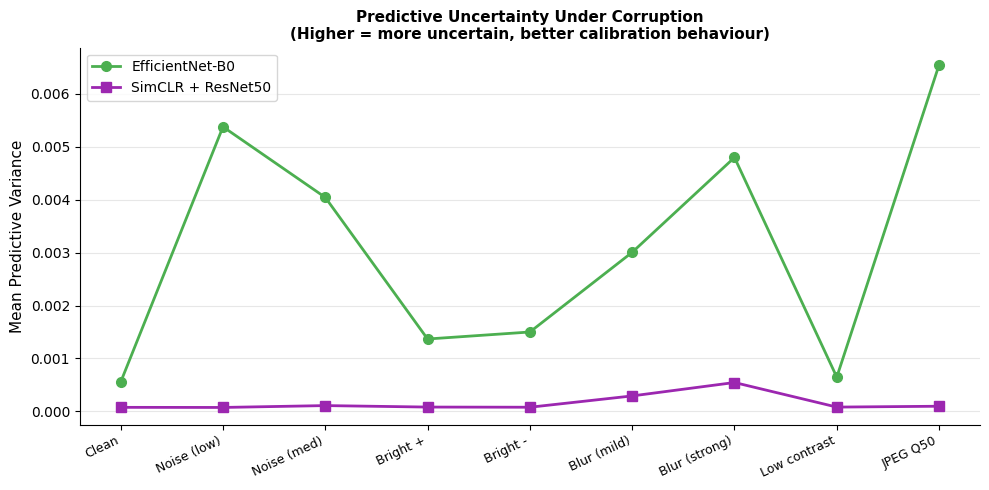

  Saved: /content/drive/MyDrive/MedSSL_Research/figures/uncertainty_under_corruption.png

  CELL 8 COMPLETE — uncertainty analysis done


In [ ]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 8 — Uncertainty Under Corruption                  ║
# ╚══════════════════════════════════════════════════════════╝

print('Running uncertainty under corruption analysis ...')

# Identify best supervised and best SSL model by clean F1
sup_models = ['resnet50_pretrained', 'resnet50_scratch',
              'efficientnet_b0', 'mobilevit_xs']
ssl_models = ['simclr_resnet50', 'mae_vits16']

def best_model_from(group, robustness_df):
    """Return model name with highest clean F1 from a group."""
    available = [m for m in group if m in robustness_df.index]
    if not available:
        return None
    return max(available, key=lambda m: robustness_df.loc[m, 'clean'])

best_sup = best_model_from(sup_models, robustness_df)
best_ssl = best_model_from(ssl_models, robustness_df)

print(f'  Best supervised : {best_sup}  '
      f'(clean F1={robustness_df.loc[best_sup,"clean"]:.4f})')
print(f'  Best SSL        : {best_ssl}  '
      f'(clean F1={robustness_df.loc[best_ssl,"clean"]:.4f})')

UNCERT_JSON = f'{RES_DIR}/uncertainty_under_corruption.json'

# ── Detect and discard stale all-zero cache ───────────────────
if os.path.exists(UNCERT_JSON):
    with open(UNCERT_JSON) as f:
        _cached = json.load(f)
    _all_zero = all(
        v == 0.0
        for model_data in _cached.values()
        for v in model_data.values()
    )
    if _all_zero:
        print('  [WARN] Cached data is all-zero (MC Dropout bug). Recomputing ...')
        os.remove(UNCERT_JSON)
    else:
        print('  Loading cached uncertainty results ...')
        uncert_data = _cached

if not os.path.exists(UNCERT_JSON):
    uncert_data = {best_sup: {}, best_ssl: {}}

    for mn in [best_sup, best_ssl]:
        if mn not in models:
            print(f'  [WARN] {mn} not loaded — skipping')
            continue
        model    = models[mn]
        mc_model = prepare_mc_model(model, mn)   # inject dropout if needed
        print(f'\n  {MODEL_LABELS[mn]}:')

        for corruption in CORRUPTIONS:
            corr_loader = DataLoader(
                MedicalImageDataset(df, test_idx,
                                    transform=SUPERVISED_VAL_TRANSFORMS),
                batch_size=32, shuffle=False,
                num_workers=0, pin_memory=True
            )
            # ── Apply corruption per batch (same approach as CELL 4) ──
            enable_mc_dropout(mc_model)
            all_pass_probs = []
            all_labels_c   = []

            with torch.no_grad():
                for imgs, labels in corr_loader:
                    imgs   = imgs.to(DEVICE)
                    imgs_c = apply_corruption(imgs, corruption)  # apply corruption
                    pass_probs = []
                    for _ in range(10):    # T=10 to save time across 9 corruptions
                        with torch.amp.autocast(device_type=DEVICE.type,
                                                enabled=(DEVICE.type == 'cuda')):
                            logits = mc_model(imgs_c)
                        probs = F.softmax(logits, dim=1).cpu().numpy()
                        pass_probs.append(probs)
                    all_pass_probs.append(np.stack(pass_probs, axis=0))
                    all_labels_c.append(labels.numpy())

            all_pass_probs = np.concatenate(all_pass_probs, axis=1)  # (T, N, C)
            variances_c    = all_pass_probs.var(axis=0)               # (N, C)
            mean_var       = float(variances_c.mean())

            uncert_data[mn][corruption] = mean_var
            print(f'    {CORRUPTION_LABELS[corruption]:<18} '
                  f'mean_var={mean_var:.6f}')

    with open(UNCERT_JSON, 'w') as f:
        json.dump(uncert_data, f, indent=2)
    print(f'\n  Saved: {UNCERT_JSON}')

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
x      = np.arange(len(CORRUPTIONS))
labels = [CORRUPTION_LABELS[c] for c in CORRUPTIONS]

for mn, style in [(best_sup, '-o'), (best_ssl, '-s')]:
    if mn not in uncert_data:
        continue
    vals  = [uncert_data[mn].get(c, np.nan) for c in CORRUPTIONS]
    color = MODEL_COLORS.get(mn, '#888888')
    ax.plot(x, vals, style, color=color, linewidth=2, markersize=7,
            label=MODEL_LABELS[mn])

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=25, ha='right', fontsize=9)
ax.set_ylabel('Mean Predictive Variance', fontsize=11)
ax.set_title('Predictive Uncertainty Under Corruption\n'
             '(Higher = more uncertain, better calibration behaviour)',
             fontsize=11, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
path_unc = f'{FIGS_DIR}/uncertainty_under_corruption.png'
plt.savefig(path_unc, dpi=FIG_DPI, bbox_inches='tight')
plt.show()
print(f'  Saved: {path_unc}')

print()
print('=' * 55)
print('  CELL 8 COMPLETE — uncertainty analysis done')
print('=' * 55)


### Temperature Scaling (Post-hoc Calibration)

Running temperature scaling on all 6 models ...

  ResNet50 (ImageNet) ...
    Optimal T = 1.5013
    ECE before=0.0270  after=0.0165  
    reduction=38.7%

  ResNet50 (Scratch) ...
    Optimal T = 1.3951
    ECE before=0.0240  after=0.0117  
    reduction=51.0%

  EfficientNet-B0 ...
    Optimal T = 1.6999
    ECE before=0.0259  after=0.0157  
    reduction=39.3%

  MobileViT-XS ...
    Optimal T = 1.5356
    ECE before=0.0312  after=0.0118  
    reduction=62.0%

  SimCLR + ResNet50 ...
    Optimal T = 1.7709
    ECE before=0.0280  after=0.0205  
    reduction=26.7%

  MAE + ViT-S/16 ...
    Optimal T = 1.2901
    ECE before=0.0267  after=0.0199  
    reduction=25.4%

Saved: /content/drive/MyDrive/MedSSL_Research/results/temperature_scaling_results.json

  Model                     T_opt  ECE_before  ECE_after   Reduction
  -----------------------------------------------------------------
  ResNet50 (ImageNet)       1.501  
                           
        0.0270     0.0165  
     

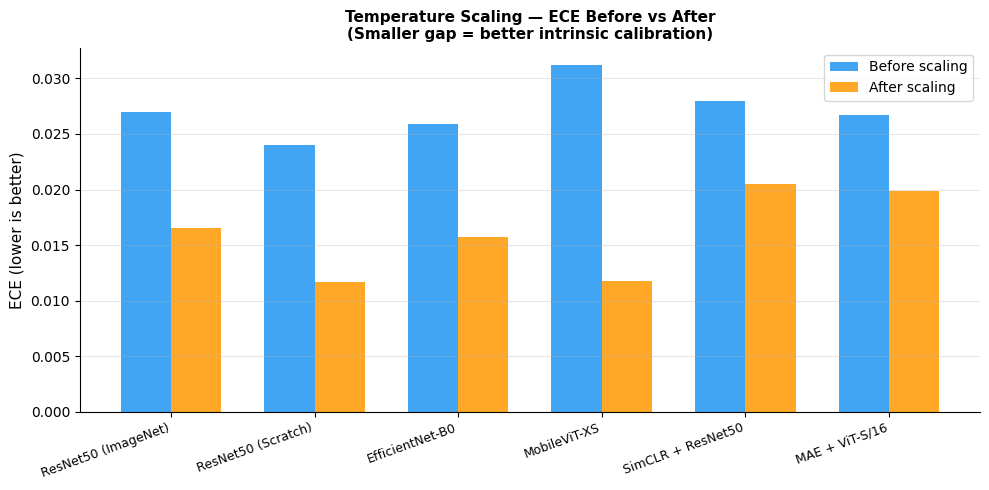

  Saved: /content/drive/MyDrive/MedSSL_Research/figures/temperature_scaling_ece.png

  CELL 8b COMPLETE — temperature scaling done


In [ ]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 9 — Temperature Scaling (Post-hoc Calibration)   ║
# ╚══════════════════════════════════════════════════════════╝
#
# Temperature scaling (Guo et al. 2017) learns a single scalar T
# on the validation set. T > 1 reduces overconfidence. Lower ECE
# after scaling = intrinsically better-calibrated representations.

TEMP_JSON = f'{RES_DIR}/temperature_scaling_results.json'


class TemperatureScaler(nn.Module):
    """
    Single-parameter post-hoc calibration wrapper (Guo et al. 2017).

    Divides logits by a learnable scalar T before softmax.
    T is fitted on the validation set via NLL minimisation.

    Parameters
    ----------
    model : nn.Module  trained model (weights frozen during T fitting)
    """

    def __init__(self, model):
        super().__init__()
        self.model       = model
        self.temperature = nn.Parameter(torch.ones(1) * 1.5)

    def forward(self, x):
        return self.model(x) / self.temperature

    def fit(self, val_loader, device, max_iter=50):
        """
        Fit temperature on validation logits using L-BFGS + NLL.

        Parameters
        ----------
        val_loader : DataLoader
        device     : torch.device
        max_iter   : int

        Returns
        -------
        float  optimal temperature value
        """
        self.model.eval()
        optimizer = torch.optim.LBFGS([self.temperature], lr=0.01,
                                       max_iter=max_iter)
        all_logits, all_labels = [], []

        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs = imgs.to(device)
                with torch.amp.autocast(device_type=device.type,
                                        enabled=(device.type == 'cuda')):
                    logits = self.model(imgs)
                all_logits.append(logits.cpu())
                all_labels.append(labels)

        all_logits = torch.cat(all_logits)
        all_labels = torch.cat(all_labels)
        criterion  = nn.CrossEntropyLoss()

        def eval_nll():
          optimizer.zero_grad()
          dev  = self.temperature.device
          loss = criterion(all_logits.to(dev) / self.temperature,
                          all_labels.to(dev))
          loss.backward()
          return loss

        optimizer.step(eval_nll)
        return float(self.temperature.item())


if os.path.exists(TEMP_JSON):
    print('Temperature scaling results already exist. Loading from Drive.')
    with open(TEMP_JSON) as f:
        temp_results = json.load(f)
else:
    print('Running temperature scaling on all 6 models ...')

    val_loader_ts = DataLoader(
        MedicalImageDataset(df, val_idx, transform=SUPERVISED_VAL_TRANSFORMS),
        batch_size=64, shuffle=False, num_workers=0, pin_memory=True
    )
    test_loader_ts = DataLoader(
        MedicalImageDataset(df, test_idx, transform=SUPERVISED_VAL_TRANSFORMS),
        batch_size=64, shuffle=False, num_workers=0, pin_memory=True
    )

    temp_results = {}

    for mn, model in models.items():
        print(f'\n  {MODEL_LABELS[mn]} ...')

        # Fit temperature on validation set
        ts    = TemperatureScaler(model).to(DEVICE)
        T_opt = ts.fit(val_loader_ts, DEVICE)
        print(f'    Optimal T = {T_opt:.4f}')

        # ECE before scaling (from mc_results if available)
        if mn in mc_results:
            ece_before = compute_ece(mc_results[mn]['mean_probs'],
                                     mc_results[mn]['true_labels'])
        else:
            ece_before = float(calibration_df.loc[MODEL_LABELS[mn], 'ECE'])

        # ECE after scaling
        ts.eval()
        all_probs_ts, all_labels_ts = [], []
        with torch.no_grad():
            for imgs, labels in test_loader_ts:
                imgs = imgs.to(DEVICE)
                with torch.amp.autocast(device_type=DEVICE.type,
                                        enabled=(DEVICE.type == 'cuda')):
                    scaled_logits = ts(imgs)
                probs = F.softmax(scaled_logits, dim=1).cpu().numpy()
                all_probs_ts.append(probs)
                all_labels_ts.append(labels.numpy())

        all_probs_ts  = np.concatenate(all_probs_ts)
        all_labels_ts = np.concatenate(all_labels_ts)
        ece_after     = compute_ece(all_probs_ts, all_labels_ts)
        reduction_pct = (ece_before - ece_after) / ece_before * 100

        temp_results[mn] = {
            'label'          : MODEL_LABELS[mn],
            'T_optimal'      : round(T_opt, 4),
            'ECE_before'     : round(ece_before, 4),
            'ECE_after'      : round(ece_after,  4),
            'ECE_reduction_%': round(reduction_pct, 1),
        }
        print(f'    ECE before={ece_before:.4f}  after={ece_after:.4f}  ')
        print(f'    reduction={reduction_pct:.1f}%')

    with open(TEMP_JSON, 'w') as f:
        json.dump(temp_results, f, indent=2)
    print(f'\nSaved: {TEMP_JSON}')

# Print summary table
W2 = 24
print()
print(f'  {"Model":<{W2}} {"T_opt":>6}  {"ECE_before":>10}  {"ECE_after":>9}  {"Reduction":>10}')
print('  ' + '-' * 65)
for mn, r in temp_results.items():
    print(f'  {r["label"]:<{W2}} {r["T_optimal"]:>6.3f}  ')
    print(f'  {"":<{W2}} ')
    print(f'    {r["ECE_before"]:>10.4f}  {r["ECE_after"]:>9.4f}  ')
    print(f'    {r["ECE_reduction_%"]:>9.1f}%')

# Figure: ECE before vs after bar chart
fig, ax = plt.subplots(figsize=(10, 5))
ts_labels   = [r['label']      for r in temp_results.values()]
ece_before_ = [r['ECE_before'] for r in temp_results.values()]
ece_after_  = [r['ECE_after']  for r in temp_results.values()]
x_ts = np.arange(len(ts_labels))
w    = 0.35
ax.bar(x_ts - w/2, ece_before_, w, label='Before scaling',
       color='#2196F3', alpha=0.85)
ax.bar(x_ts + w/2, ece_after_,  w, label='After scaling',
       color='#FF9800', alpha=0.85)
ax.set_xticks(x_ts)
ax.set_xticklabels(ts_labels, rotation=20, ha='right', fontsize=9)
ax.set_ylabel('ECE (lower is better)', fontsize=11)
ax.set_title('Temperature Scaling — ECE Before vs After\n'
             '(Lower ECE after scaling = less correction needed = ')
ax.set_title('Temperature Scaling — ECE Before vs After\n'
             '(Smaller gap = better intrinsic calibration)',
             fontsize=11, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
path_ts = f'{FIGS_DIR}/temperature_scaling_ece.png'
plt.savefig(path_ts, dpi=FIG_DPI, bbox_inches='tight')
plt.show()
print(f'  Saved: {path_ts}')

print()
print('=' * 55)
print('  CELL 8b COMPLETE — temperature scaling done')
print('=' * 55)


### Multi-Severity Corruption Curves

Running multi-severity corruption evaluation ...

  ResNet50 (ImageNet):
    gaussian_noise  sev=0.01  F1=0.9305
    gaussian_noise  sev=0.03  F1=0.9238
    gaussian_noise  sev=0.05  F1=0.9088
    gaussian_noise  sev=0.08  F1=0.8379
    gaussian_noise  sev=0.10  F1=0.7680
    gaussian_blur  sev=0.50  F1=0.8739
    gaussian_blur  sev=1.00  F1=0.5174
    gaussian_blur  sev=1.50  F1=0.4152
    gaussian_blur  sev=2.00  F1=0.3526
    gaussian_blur  sev=2.50  F1=0.2903

  ResNet50 (Scratch):
    gaussian_noise  sev=0.01  F1=0.8955
    gaussian_noise  sev=0.03  F1=0.8952
    gaussian_noise  sev=0.05  F1=0.8965
    gaussian_noise  sev=0.08  F1=0.8951
    gaussian_noise  sev=0.10  F1=0.8899
    gaussian_blur  sev=0.50  F1=0.8926
    gaussian_blur  sev=1.00  F1=0.8727
    gaussian_blur  sev=1.50  F1=0.8120
    gaussian_blur  sev=2.00  F1=0.7255
    gaussian_blur  sev=2.50  F1=0.6282

  EfficientNet-B0:
    gaussian_noise  sev=0.01  F1=0.9489
    gaussian_noise  sev=0.03  F1=0.8554
    gaussian_n

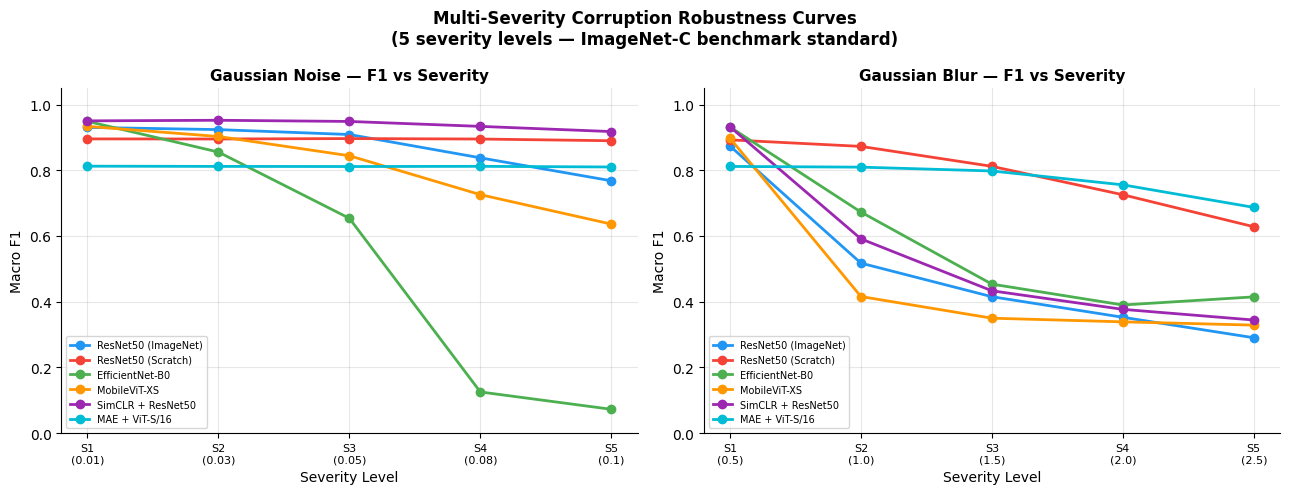

  Saved: /content/drive/MyDrive/MedSSL_Research/figures/multi_severity_curves.png

  CELL 8c COMPLETE — multi-severity curves done


In [ ]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 10 — Multi-Severity Corruption Curves             ║
# ╚══════════════════════════════════════════════════════════╝
#
# Extends robustness evaluation to 5 severity levels for Gaussian
# noise and Gaussian blur — matches the ImageNet-C benchmark standard.
# Produces severity curves showing how quickly each model degrades.
# Uses the same apply_corruption() + evaluate_corrupted() pattern as CELL 4.

SEVERITY_CSV = f'{RES_DIR}/multi_severity_robustness.csv'

SEVERITY_CORRUPTIONS = {
    'gaussian_noise': [0.01, 0.03, 0.05, 0.08, 0.10],   # sigma
    'gaussian_blur'  : [0.5,  1.0,  1.5,  2.0,  2.5],    # sigma
}


def apply_severity_corruption(imgs, corruption_type, severity):
    """
    Apply a parametric corruption at a specific severity level.
    Uses kornia for GPU-accelerated transforms, consistent with CELL 3.

    Parameters
    ----------
    imgs           : Tensor (B, 3, 224, 224)  normalised batch on GPU
    corruption_type: str   'gaussian_noise' | 'gaussian_blur'
    severity       : float severity parameter value

    Returns
    -------
    Tensor (B, 3, 224, 224)  corrupted batch
    """
    x = imgs.float()
    if corruption_type == 'gaussian_noise':
        return x + torch.randn_like(x) * severity
    elif corruption_type == 'gaussian_blur':
        ks = max(3, int(severity * 6) | 1)   # kernel must be odd
        blur = K.RandomGaussianBlur((ks, ks), (severity, severity), p=1.0)
        return blur(x)
    else:
        raise ValueError(f'Unknown severity corruption: {corruption_type}')


if os.path.exists(SEVERITY_CSV):
    print('Multi-severity results already exist. Loading from Drive.')
    severity_df = pd.read_csv(SEVERITY_CSV)
else:
    print('Running multi-severity corruption evaluation ...')
    sev_records = []

    for mn, model in models.items():
        print(f'\n  {MODEL_LABELS[mn]}:')
        model.eval()
        for corr_type, severities in SEVERITY_CORRUPTIONS.items():
            for sev_idx, severity in enumerate(severities):
                all_preds, all_labels_s = [], []
                with torch.no_grad():
                    for imgs, labels in base_test_loader:
                        imgs   = imgs.to(DEVICE)
                        imgs_c = apply_severity_corruption(imgs, corr_type, severity)
                        with torch.amp.autocast(device_type=DEVICE.type,
                                                enabled=(DEVICE.type == 'cuda')):
                            logits = model(imgs_c)
                        preds = logits.argmax(dim=1)
                        all_preds.extend(preds.cpu().numpy())
                        all_labels_s.extend(labels.numpy())

                f1 = float(f1_score(all_labels_s, all_preds,
                                    average='macro', zero_division=0))
                sev_records.append({
                    'model'          : mn,
                    'model_label'    : MODEL_LABELS[mn],
                    'corruption_type': corr_type,
                    'severity_level' : sev_idx + 1,
                    'severity_value' : severity,
                    'macro_f1'       : round(f1, 4),
                })
                print(f'    {corr_type}  sev={severity:.2f}  F1={f1:.4f}')

    severity_df = pd.DataFrame(sev_records)
    severity_df.to_csv(SEVERITY_CSV, index=False)
    print(f'\nSaved: {SEVERITY_CSV}')

# Plot severity curves
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, corr_type in zip(axes, SEVERITY_CORRUPTIONS.keys()):
    sev_vals = SEVERITY_CORRUPTIONS[corr_type]
    sub      = severity_df[severity_df['corruption_type'] == corr_type]
    for mn in MODEL_NAMES:
        m_sub = sub[sub['model'] == mn].sort_values('severity_level')
        if m_sub.empty:
            continue
        ax.plot(m_sub['severity_level'].values,
                m_sub['macro_f1'].values,
                '-o', color=MODEL_COLORS.get(mn, '#888888'),
                linewidth=2.0, markersize=6,
                label=MODEL_LABELS.get(mn, mn))
    ax.set_xticks(range(1, 6))
    ax.set_xticklabels(
        [f'S{i+1}\n({v})' for i, v in enumerate(sev_vals)],
        fontsize=8)
    ax.set_xlabel('Severity Level', fontsize=10)
    ax.set_ylabel('Macro F1', fontsize=10)
    title = ('Gaussian Noise' if 'noise' in corr_type else 'Gaussian Blur')
    ax.set_title(f'{title} — F1 vs Severity',
                 fontsize=11, fontweight='bold')
    ax.legend(fontsize=7, loc='lower left')
    ax.set_ylim(0, 1.05)
    ax.grid(alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle('Multi-Severity Corruption Robustness Curves\n'
             '(5 severity levels — ImageNet-C benchmark standard)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
path_sev = f'{FIGS_DIR}/multi_severity_curves.png'
plt.savefig(path_sev, dpi=FIG_DPI, bbox_inches='tight')
plt.show()
print(f'  Saved: {path_sev}')

print()
print('=' * 55)
print('  CELL 8c COMPLETE — multi-severity curves done')
print('=' * 55)


### Status Summary

In [ ]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 9 — Status Summary                                ║
# ╚══════════════════════════════════════════════════════════╝

def fstat(path):
    return 'OK' if os.path.exists(path) else 'MISSING'

# Best robustness model
best_robust_model = robustness_df['avg_drop_pct'].idxmin()
best_robust_drop  = robustness_df.loc[best_robust_model, 'avg_drop_pct']

# Best calibrated
best_calib_model = calibration_df['ECE'].idxmin()
best_calib_ece   = calibration_df.loc[best_calib_model, 'ECE']

# Most overconfident
most_overconf_model = calibration_df['Overconfidence%'].idxmax()
most_overconf_val   = calibration_df.loc[most_overconf_model, 'Overconfidence%']

W = 48
print('=' * (W + 15))
print('  NOTEBOOK 4 — STATUS SUMMARY')
print('=' * (W + 15))
print(f'  {"Corruptions evaluated":<{W}} 8 + clean baseline')
print(f'  {"Best robustness":<{W}} {best_robust_model}')
print(f'  {"  avg F1 drop":<{W}} {best_robust_drop:.2f}%')
print(f'  {"Best calibrated model":<{W}} {best_calib_model}')
print(f'  {"  ECE":<{W}} {best_calib_ece:.4f}')
print(f'  {"Most overconfident model":<{W}} {most_overconf_model}')
print(f'  {"  Overconfidence score":<{W}} {most_overconf_val:.1f}%')
print()
files = {
    'robustness_results.csv'            : ROBUSTNESS_CSV,
    'calibration_results.csv'           : CALIBRATION_CSV,
    'robustness_barchart.png'           : f'{FIGS_DIR}/robustness_barchart.png',
    'robustness_heatmap.png'            : f'{FIGS_DIR}/robustness_heatmap.png',
    'reliability_diagrams_6models.png'  : f'{FIGS_DIR}/reliability_diagrams_6models.png',
    'confidence_histograms.png'         : f'{FIGS_DIR}/confidence_histograms.png',
    'uncertainty_under_corruption.png'  : f'{FIGS_DIR}/uncertainty_under_corruption.png',
    'temperature_scaling_ece.png'        : f'{FIGS_DIR}/temperature_scaling_ece.png',
    'multi_severity_curves.png'          : f'{FIGS_DIR}/multi_severity_curves.png',
}
for name, path in files.items():
    print(f'  {name:<{W}} {fstat(path)}')

missing_files = [p for p in files.values() if not os.path.exists(p)]
print()
if missing_files:
    status = f'INCOMPLETE — {len(missing_files)} files missing'
else:
    status = 'READY FOR NOTEBOOK 5'
print(f'  STATUS: {status}')
print('=' * (W + 15))

  NOTEBOOK 4 — STATUS SUMMARY
  Corruptions evaluated                            8 + clean baseline
  Best robustness                                  mae_vits16
    avg F1 drop                                    2.28%
  Best calibrated model                            ResNet50 (Scratch)
    ECE                                            0.0240
  Most overconfident model                         EfficientNet-B0
    Overconfidence score                           67.3%

  robustness_results.csv                           OK
  calibration_results.csv                          OK
  robustness_barchart.png                          OK
  robustness_heatmap.png                           OK
  reliability_diagrams_6models.png                 OK
  confidence_histograms.png                        OK
  uncertainty_under_corruption.png                 OK
  temperature_scaling_ece.png                      OK
  multi_severity_curves.png                        OK

  STATUS: READY FOR NOTEBOOK 5
